In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\vinod\Downloads\P668 DATASET.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(df.head())

                 Open       High        Low      Close  Adj Close    Volume
Date                                                                       
2012-01-03  58.485714  58.928570  58.428570  58.747143  50.765709  75555200
2012-01-04  58.571430  59.240002  58.468571  59.062859  51.038536  65005500
2012-01-05  59.278572  59.792858  58.952858  59.718571  51.605175  67817400
2012-01-06  59.967144  60.392857  59.888573  60.342857  52.144630  79573200
2012-01-09  60.785713  61.107143  60.192856  60.247143  52.061932  98506100


In [4]:
# Missing values check
print(df.isnull().sum())

# Fill if any missing
df.fillna(method='ffill', inplace=True)

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


C:\Users\vinod\AppData\Local\Temp\ipykernel_15300\3766431310.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


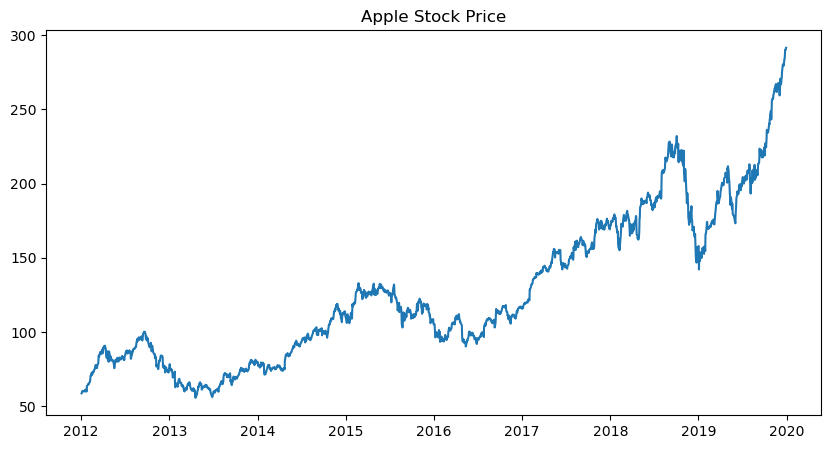

In [5]:
# EDA (exploratory data anylysis)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Apple Stock Price")
plt.show()

KeyError: 'MA10'

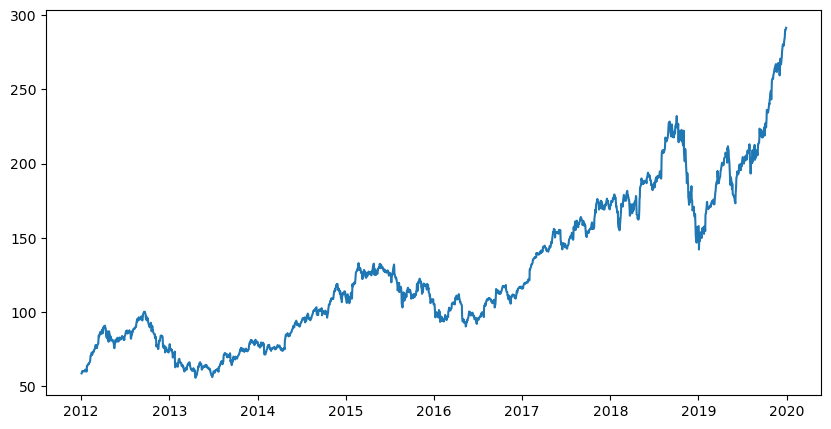

In [6]:
# Moving Average
plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Close')
plt.plot(df['MA10'], label='MA10')
plt.plot(df['MA50'], label='MA50')

plt.legend()
plt.title("Trend with Moving Averages")
plt.show()

In [ ]:
# HISTOGRAM
plt.figure(figsize=(8,5))
df['Close'].hist(bins=30)
plt.title("Histogram of Close Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Multiple Histogram 
df[['Open','High','Low','Close']].hist(figsize=(10,8))
plt.suptitle("Histogram of Stock Features")
plt.show()



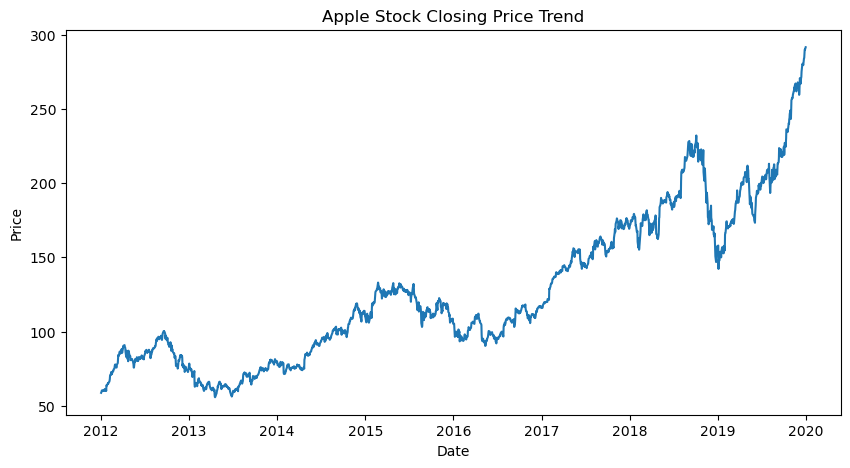

In [7]:
# LINE PLOT 
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Apple Stock Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


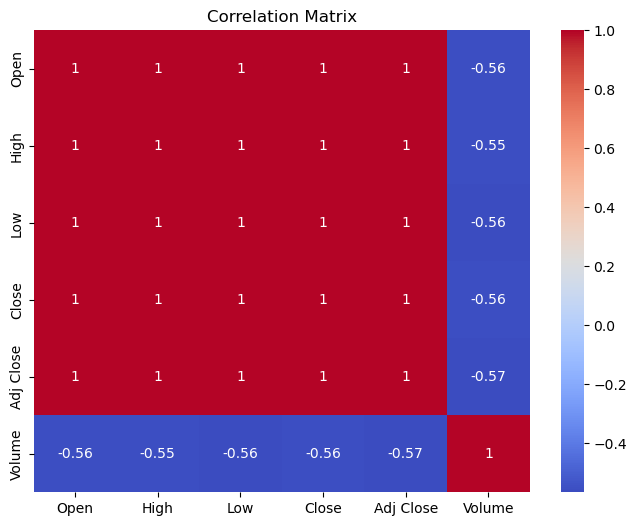

In [8]:
# CORRELATION MATRIX 
plt.figure(figsize=(8,6))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [9]:
# MODEL BUILDING
data = df[['Close']]

train_size = int(len(data)*0.8)
train = data[:train_size]
test = data[train_size:]

In [10]:
# ARIMA
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

arima_pred = model_fit.forecast(len(test))

C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\U

In [11]:
# SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit()

sarima_pred = model_fit.forecast(len(test))

C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_predict

In [12]:
# XGBoost
from xgboost import XGBRegressor

df['lag1'] = df['Close'].shift(1)
df['lag2'] = df['Close'].shift(2)

df.dropna(inplace=True)

X = df[['lag1','lag2']]
y = df['Close']

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = XGBRegressor()
model.fit(X_train, y_train)

xgb_pred = model.predict(X_test)

In [13]:
# Model Evalution 
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def check(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    print("RMSE:", rmse)
    print("MAE:", mae)

print("ARIMA")
check(test, arima_pred)

print("SARIMA")
check(test, sarima_pred)

print("XGBoost")
check(y_test, xgb_pred)

ARIMA
RMSE: 34.00632826447743
MAE: 25.361440250378465
SARIMA
RMSE: 26.345766851685116
MAE: 20.78841961369555
XGBoost
RMSE: 32.688824572412415
MAE: 21.954114012918808


In [14]:
# NEXT 30 DAYS FORECAST
final_model = ARIMA(data, order=(5,1,0))
final_fit = final_model.fit()

forecast = final_fit.forecast(steps=30)

print(forecast)

C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


2011    291.543586
2012    291.659058
2013    291.732665
2014    291.783712
2015    291.812519
2016    291.813492
2017    291.815897
2018    291.818495
2019    291.820349
2020    291.820790
2021    291.820760
2022    291.820839
2023    291.820946
2024    291.820995
2025    291.820996
2026    291.820994
2027    291.820998
2028    291.821002
2029    291.821003
2030    291.821003
2031    291.821003
2032    291.821003
2033    291.821003
2034    291.821003
2035    291.821003
2036    291.821003
2037    291.821003
2038    291.821003
2039    291.821003
2040    291.821003
Name: predicted_mean, dtype: float64


C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


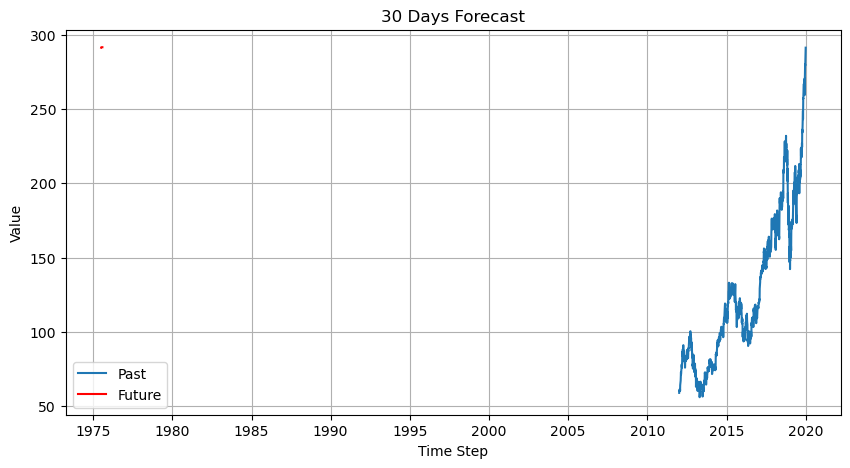

In [15]:
# VISUALIZATION

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(data, label='Past')

forecast = forecast[:30]  # only 30 days

forecast_x = np.arange(len(data), len(data) + len(forecast))
plt.plot(forecast_x, forecast, label='Future', color='red')

plt.xlabel("Time Step")
plt.ylabel("Value")
plt.title("30 Days Forecast")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
# Deployment 
import streamlit as st
import pandas as pd

st.title("Apple Stock Prediction")

forecast = pd.read_csv("forecast.csv")

st.line_chart(forecast)

2026-04-28 12:48:57.786 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 12:48:58.113 
  command:

    streamlit run C:\Users\vinod\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-28 12:48:58.114 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 12:48:58.115 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


FileNotFoundError: [Errno 2] No such file or directory: 'forecast.csv'